# Performance Comparison: Pandas vs PySpark

### Student: Islas Carreon Victor Jakxel

## Objective

Evaluate large-scale data processing performance using in-memory, single-process
processing with Pandas and distributed computing with PySpark.

The same operations will be performed on a dataset, and the execution times
of both technologies will be compared.

In [ ]:
!pip install pyspark

In [ ]:
import pandas as pd
import numpy as np
import time

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [ ]:
spark = (
    SparkSession.builder
    .appName("Pandas_vs_PySpark")
    .master("local[*]")
    .getOrCreate()
)

spark

In [ ]:
N = 1_000_000

np.random.seed(42)

df = pd.DataFrame({
    "id": np.arange(N),
    "product": np.random.choice(
        ["Laptop", "Phone", "Tablet", "Monitor", "Keyboard"],
        N
    ),
    "category": np.random.choice(
        ["Technology", "Accessories", "Computing"],
        N
    ),
    "city": np.random.choice(
        ["Los Angeles", "New York", "Chicago", "Houston", "Miami"],
        N
    ),
    "quantity": np.random.randint(1, 20, N),
    "price": np.random.uniform(10, 2000, N)
})

df["total"] = df["quantity"] * df["price"]

df.head()

,id,product,category,city,quantity,price,total
0,0,Monitor,Technology,Miami,6,1160.669092,6964.014551
1,1,Keyboard,Computing,Chicago,16,1649.301555,26388.824873
2,2,Tablet,Accessories,Los Angeles,10,279.978389,2799.783891
3,3,Keyboard,Accessories,Miami,12,1389.614201,16675.370406
4,4,Keyboard,Accessories,Los Angeles,10,42.100397,421.003969


In [ ]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Memory used: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Rows: 1,000,000
Columns: 7
Memory used: 194.10 MB


In [ ]:
pandas_start = time.perf_counter()

pandas_result = (
    df[df["quantity"] > 5]
    .groupby("category")
    .agg(
        total_quantity=("quantity", "sum"),
        total_sales=("total", "sum")
    )
    .reset_index()
)

pandas_end = time.perf_counter()

pandas_time = pandas_end - pandas_start

print(f"Pandas time: {pandas_time:.4f} seconds")

pandas_result

Pandas time: 0.1515 seconds


,category,total_quantity,total_sales
0,Accessories,3082076,3.099458e+09
1,Computing,3076789,3.087492e+09
2,Technology,3059883,3.080036e+09


In [ ]:
df_spark = spark.createDataFrame(df)

df_spark.printSchema()

root
 |-- id: long (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- city: string (nullable = true)
 |-- quantity: long (nullable = true)
 |-- price: double (nullable = true)
 |-- total: double (nullable = true)



In [ ]:
print(f"Spark rows: {df_spark.count():,}")

Spark rows: 1,000,000


In [ ]:
spark_start = time.perf_counter()

spark_result = (
    df_spark
    .filter(F.col("quantity") > 5)
    .groupBy("category")
    .agg(
        F.sum("quantity").alias("total_quantity"),
        F.sum("total").alias("total_sales")
    )
)

spark_result.show()

spark_end = time.perf_counter()

spark_time = spark_end - spark_start

print(f"PySpark time: {spark_time:.4f} seconds")

+-----------+--------------+--------------------+
|  category|total_quantity|      total_sales|
+-----------+--------------+--------------------+
| Accessories|       3082076|3.0994582079538765E9|
|Computing|       3076789|3.0874918055675154E9|
| Technology|       3059883| 3.080035604316799E9|
+-----------+--------------+--------------------+

PySpark time: 6.3679 seconds


In [ ]:
spark_result_pd = spark_result.toPandas()

spark_result_pd

,category,total_quantity,total_sales
0,Accessories,3082076,3.099458e+09
1,Computing,3076789,3.087492e+09
2,Technology,3059883,3.080036e+09


In [ ]:
pandas_result = pandas_result.sort_values("category").reset_index(drop=True)

spark_result_pd = spark_result_pd.sort_values("category").reset_index(drop=True)

pandas_result

,category,total_quantity,total_sales
0,Accessories,3082076,3.099458e+09
1,Computing,3076789,3.087492e+09
2,Technology,3059883,3.080036e+09


In [ ]:
spark_result_pd

,category,total_quantity,total_sales
0,Accessories,3082076,3.099458e+09
1,Computing,3076789,3.087492e+09
2,Technology,3059883,3.080036e+09


In [ ]:
pd.testing.assert_frame_equal(
    pandas_result,
    spark_result_pd,
    check_dtype=False
)

print("The results are equivalent.")

The results are equivalent.


In [ ]:
comparison = pd.DataFrame({
    "Technology": ["Pandas", "PySpark"],
    "Time_seconds": [
        pandas_time,
        spark_time
    ]
})

comparison

,Technology,Time_seconds
0,Pandas,0.151510
1,PySpark,6.367949


In [ ]:
if pandas_time > spark_time:
    speed_ratio = pandas_time / spark_time
    print(f"PySpark was approximately {speed_ratio:.2f}x faster.")
else:
    speed_ratio = spark_time / pandas_time
    print(f"Pandas was approximately {speed_ratio:.2f}x faster.")

Pandas was approximately 42.03x times faster.


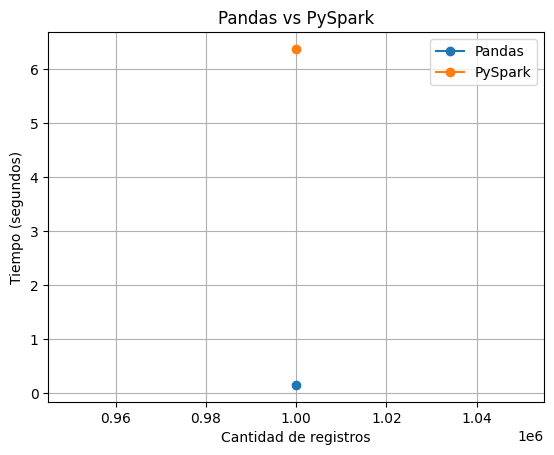

In [ ]:
import matplotlib.pyplot as plt

sizes = [N]
pandas_times = [pandas_time]
spark_times = [spark_time]

plt.plot(sizes, pandas_times, marker="o", label="Pandas")
plt.plot(sizes, spark_times, marker="o", label="PySpark")

plt.xlabel("Number of rows")
plt.ylabel("Time (seconds)")
plt.title("Pandas vs PySpark")
plt.legend()
plt.grid(True)

plt.show()